# Полносвязные нейронные сети (многослойный персептрон). Решение задач регрессии и классификации

## Искусственные нейроны

Искусственными нейронными сетями (чаще - просто нейронными сетями) называются модели машинного обучения, в основе функционирования которых лежат <b>принципы работы биологических нейронов</b> в человеческом мозге.

Идея, лежащая в основе нейронных сетей, очень простая: каждый биологический нейрон имеет несколько входов (дендритов), на основе информации с которых формируется выходной сигнал, который с помощью выхода (аксона) передается далее к органам человеческого (и не только) организма. В 1943 году У. Маккалок и У. Питтс предложили идею искусственного нейрона.

![](https://upload.wikimedia.org/wikipedia/ru/thumb/b/ba/Single_layer_perceptron.png/270px-Single_layer_perceptron.png)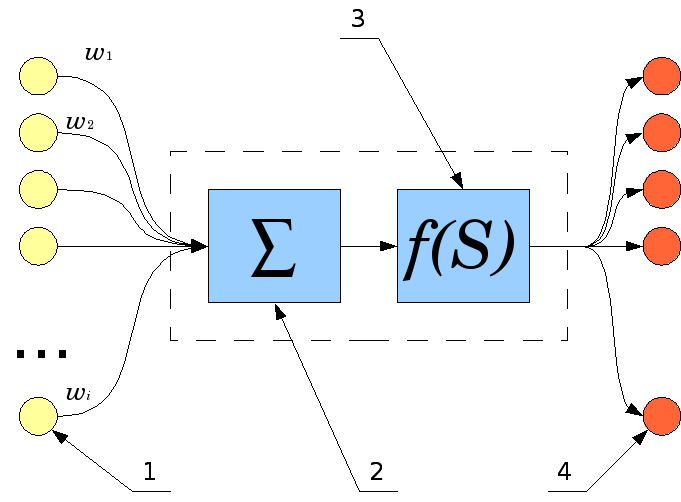

Искусственный нейрон также имеет дендриты и аксон. Математически, здесь на вход нейрона подается некоторый вектор из чисел $x$. При этом каждый дендрит имеет свой вес $w$. Значение нейрона $h$ вычисляется как $h=wx^T$, если в векторной форме. А если в скалярной, то речь идет о простом перемножении компонент входного вектора на соответствующие веса связей и последующее суммирование.

Заметим, что такой нейрон полностью эквивалентен линейному регрессору, а это значит, что он может находить в данных исключительно линейные зависимости. Чтобы такого не было придумали передавать аксону не $h$, а $f(h)$, где $f$ - нелинейная функция, называемая <b>функцией активации</b>.

Функции активации способны управлять множеством значений нейрона. Ниже приведены некоторые функции активации.

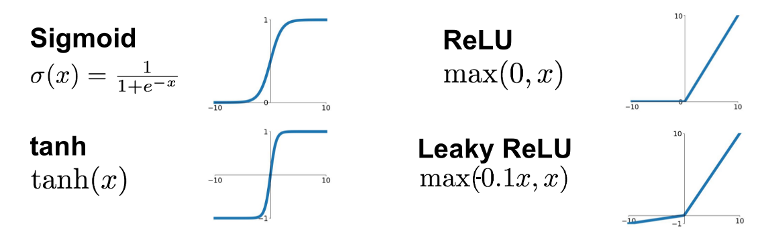

## Полносвязные нейронные сети. Получение предсказаний

Со временем идея искусственных нейронов была обобщена. Появились модели, в которых уже присутствовало несколько взаимосвязанных между собой нейронов. Исторически первым прикладным обобщением сетей из искусственных нейронов является <b>многослойный персептрон</b>. Его концепция была предложена Ф. Розенблатом в 1958 году. Однако персептрон Розенблата имел всего три слоя. Мы же будем рассматривать обобщенную модель.

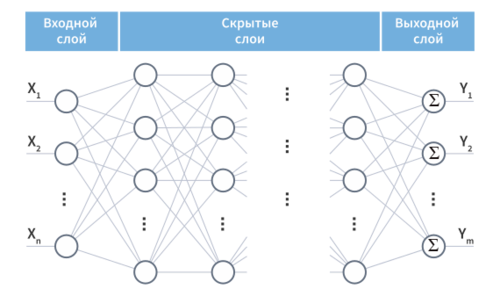

Представленая выше нейронная сеть (многослойный персептрон) называется <b>полносвязной</b>. Это означает, что каждый нейрон текущего слоя связан с каждым нейроном предыдущего слоя. Если скрытых нейронов больше чем один, то такая сеть называется <b>глубокой</b>. Обучение глубоких нейронных сетей называется глубоким обучением.

В сети выделяют входной слой (нейроны, на которых просто размещается вектор входных значений), скрытые слои (у каждого слоя своя функция активации, которую используют все нейроны) и выходной слой (функция активации выходного слоя отображает значения суммы в требуемое множество значений). Вы, наверное, догадались, что в случае регрессии функция активации выходного слоя, как правило, не ограничивает значения нейронов (то есть может вообще не применяться), может отображать значения нейрона в положительное число (например, relu). В случае классификации в большинстве случаев используются функции активации sigmoid и softmax. Как именно они применяются вы увидите на практике ниже.

Получение предсказаний с помощью нейронной сети - это <b>процесс последовательного выполнения матричного умножения с последующим поэлементным применением функции активации к получившемуся вектору<b>. Не верите? давайте это увидим.

Каждому слою сети (кроме входного) соответствует матрица обучаемых параметров. Пусть мы рассматриваем первых скрытый слой, обозначим количество его нейронов за $m$. Обозначим количество нейронов предыдущего слоя (входного) за $n$. Тогда матрица весов слоя $W$ будет иметь размерность $m{\times}n$. Элемент $w_{ij}$ - вес связи $i$ нейрона текущего слоя с $j$ нейроном предыдущего.

Также каждому слою соответствует собственный вектор $b$ - это значение сдвига. Количество элементов вектора b соответствует количеству нейронов текущего слоя. Значения нейронов текущего слоя $h$ вычисляется как $h=Wx+b$. Выходное значение нейронов вычисляется как $f(h)$, где $f$ - функция активации текущего слоя.

Как вы видите, получить предсказания очень просто. Изначально значения W и b каждого слоя инициализируются случайным образом. Вы понимаете, что для получения адекватных предсказаний нам необходимо выполнить обучение, то есть <b>найти значения W и b для каждого слоя сети, которые позволят минимизировать функцию ошибки</b>.

## Обучение полносвязных нейронных сетей. Алгоритм обратного распространения ошибки

Обучение нейронной сети производится с использованием подходов, в основе которых лежит градиентный спуск. В самом простом случае - это обычный, уже знакомый нам, метод наискорейшего спуска. Но вот задача - все эти методы требуют расчета градиента функции ошибки. А как нам посчитать градиент функции ошибки при использовании нейронной сети? Оказывается, что в этом случае мы не можем просто взять и посчитать сразу весь градиент. Вместо этого, мы можем вычислить его по отдельным частям. Алгоритм вычисления градиента, используемый при обучении нейронных сетей, получил название <b>метод обратного распространения ошибки (backpropagation)</b>. Понимание его работы - это основа вашего понимания работы нейронных сетей.

Суть метода обратного распространения ошибки заключается в том, что мы после получения конечных предсказаний начинаем идти назад (от последнего слоя к первому) и последовательно вычислять части градиента. Как вы, наверное, догадались, обучаемыми параметрами у нас являются $W$ и $b$ для каждого слоя. Мы двигаемся начиная с последнего слоя и последовательно вычисляем эти градиенты.

Для того, чтобы нам удобно было все это понять, давайте каждый слой разобьем еще на два слоя. Для простоты сделаем так, что вся сеть имеет только входной слой и выходной (выходной разбит на два отдельных слоя).

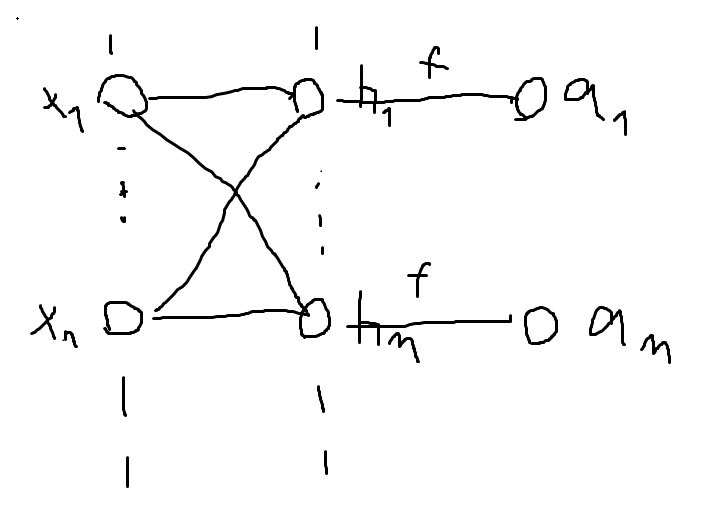

Мы видим, что любую нейронную сеть таким образом можно разбить на большее количество слоев, если каждый слой с функцией активации разбить на два слоя. Представить, что на первом выполняется суммирование произведений (умножение матрицы на вектор и добавление сдвига), а на втором - поэлементное применение функции активации. Продолжая подобные рассуждения, мы придем к тому, что любая полносвязная сеть может быть представлена как набор последовательных компонентов, каждый из которых можно рассматривать как функцию.

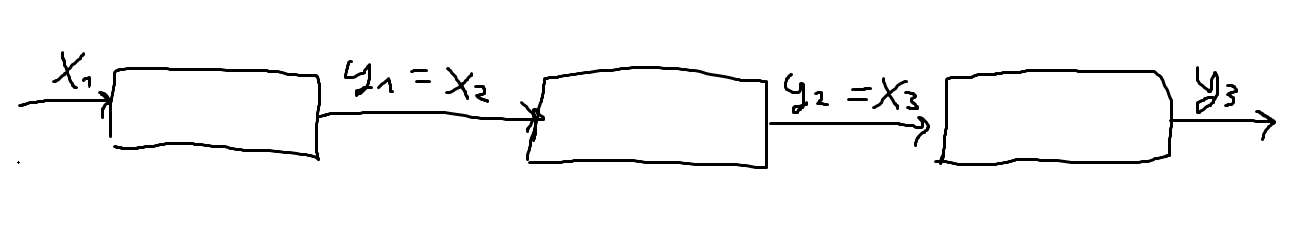

Каждый такой компонент берет входные данные и преобразует их в выходные (в случае полносвязной нейронной сети компонент либо выполняет линейное преобразование, либо применяет функцию активации). Входные данные текущего блока являются выходными данными предыдущего. Но посмотрите, а что представляют собой тогда выходные данные последнего компонента с математической точки зрения? Это ни что иное, как результат применения <b>сложной функции</b> к входным данным. В данном случае, $y_3=f_3(f_2(f_1(x_1)))$. А теперь давайте вспомним, что каждый эти компоненты содержат обучаемые параметры $W$ и $b$. В данном случае у нас есть $W_1$ и $b_1$, а также $W_3$ и $b_3$ (второй компонент не содержит обучающих параметров, поскольку отвечает за просто поэлементное применение функции активации).

Но мы с вами ранее сказали о том, что градиент вычисляется частично и по каждому множеству обучаемых параметров, так? Да, все именно так. Мат. анализ предоставляет нам замечательный инструмент для вычисления производных сложной функции - <b>цепное правило (chain rule)</b>.

Суть цепного правила вы помните со школы: если $y=y(g(x))$, то ${\frac{dy}{dx}}={\frac{dy}{dg}}{\frac{dg}{dx}}$. То же самое работает и в нашем случае. Каждый компонент использует значения частных производных функции потерь по своему выходу для непосредственного вычисления частных производных функции потерь по $W$ и $b$, а также передает предыдущему компоненту вычисленные значения производной функии потерь по своему входу. Далее компонент с использованием оптимизатора делает шаг градиентного спуска (обновляются значения весов $W$ и $b$). <b>Обращаю внимание: обновление весов выполняется ПОСЛЕ вычисления частных производных по весам</b>.

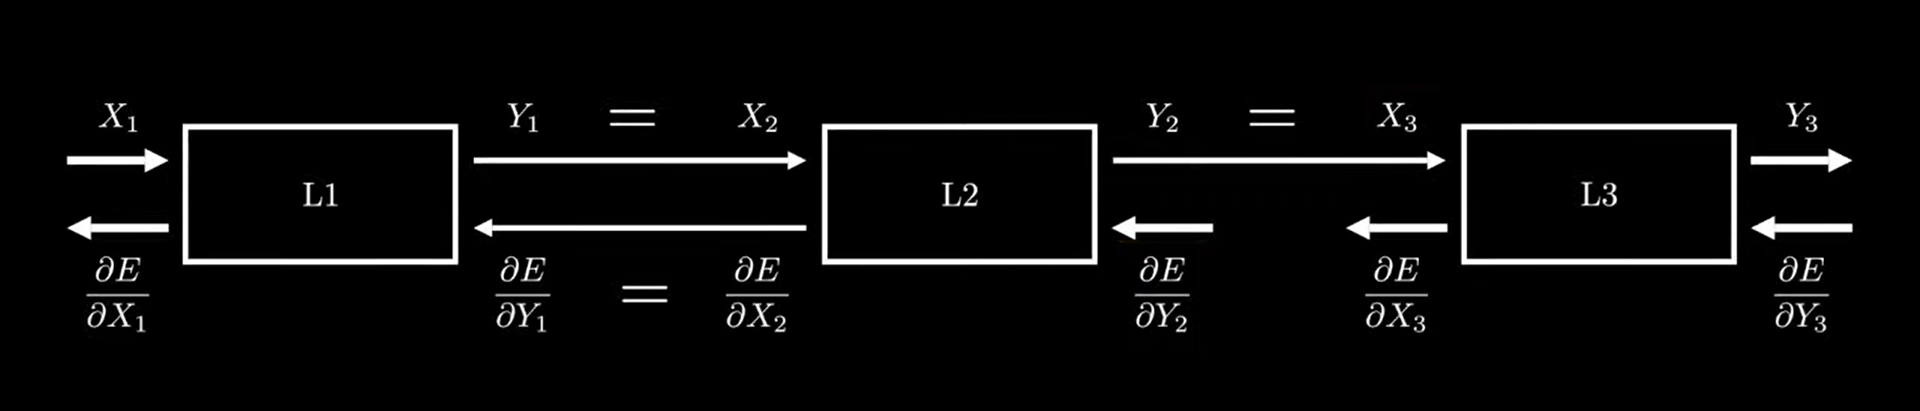

Итак, пусть у нас задана функция потерь. Для регрессии и бинарной классификации можно использовать модифицированную MSE: $E={\frac{1}{2}}(y-\hat{y})^2$. Мы хотим ее минимизировать. Ранее мы буквой $L$ обозначали функцию потерь, а при работе с нейронными сетями устоялось обозначение $E$.

Осталось разобраться, по каким формулам вычисляются части градиента в каждом компоненте. Мы знаем, что в каждом компоненте вычисляется $\frac{\partial{E}}{\partial{x}}$. В некоторых компонентах вычисляются $\frac{\partial{E}}{\partial{W}}$ и $\frac{\partial{E}}{\partial{b}}$.

Запишем формулы:

$\frac{\partial{E}}{\partial{W}}$ = $\frac{\partial{E}}{\partial{y}}x^T$

$\frac{\partial{E}}{\partial{b}}$ = $\frac{\partial{E}}{\partial{y}}$

Частные производные функции потерь по входу вычисляются по разному, в зависимости от назначения компонента. Если это компонент, реализующий линейное преобразование ($Wx+b$), то $\frac{\partial{E}}{\partial{x}} = W^T\frac{\partial{E}}{\partial{y}} $. Если это компонент, применяющий функцию активации $f$ (sigmoid, tanh, relu), то $\frac{\partial{E}}{\partial{x}} = \frac{\partial{E}}{\partial{y}}\odot f'(x) $. $\odot$ - это поэлементное произведение векторов (произведение Адамара).

Можно увидеть, что все функции активации слоев обязаны быть дифференцируемыми.

При решении задач классификации (в общем случае, когда количество классов больше двух), как правило, применяется функция потерь перекрестная энтропия (при бинарной классификации применяется ее частный случай - бинарная перекрестная кросэнтропия). Выглядит она следующим образом:

Общий случай: $E = -\sum_{k}^{s}{{y_k}ln{\hat{y_k}}}$. Здесь s - количество классов. При использовании такой функции потерь, предполагается, что целевой признак размечен (например, для случая двух классов) как [1, 0]. Это оначает, что объект относится к 0 классу. Предположим, модель предсказала ответ [0,36, 0,64]. Она ошиблась. Можно посчитать значение перекрестной энтропии и обновить веса.

Как вы видите, использование перекрестной энтропии требует, чтобы сумма значений нейронов была единица и все числа были положительными. Для получения такого результата на произвольном слое с нейронами используется функция softmax. Ее можно назвать функцией активации, однако при использовании softmax $\frac{\partial{E}}{\partial{x}}$ считается по другому. $\frac{\partial{E}}{\partial{x}} = ((1-y^T)y)\frac{\partial{E}}{\partial{y}} $. Подчеркну, что 1 здесь обозначена единичная матрица.

Вот и все. Теперь вы можете реализовать собственную полносвязную нейронную сеть. Для облегчения задачи представьте ее в виде компонентов, как это описано выше. Чтобы начать вычисление градиента необходимо начать двигаться от последнего компонента к первому, при этом предварительно посчитать частную производную функции потерь по выходу последнего компонента.

## Использование фреймворка TensorFlow и API Keras для построеония нейронных сетей

Мы разобрались, как работают полносвязные нейронные сети. Давайте теперь решим задачи регрессии и классификации с помощью фреймворка TensorFlow. Начнем с загрузки предварительно обработанных данных.

In [1]:
import pandas as pd
data_regression = pd.read_csv("../data/Regression_wine_quality_filtered.csv").head(1000)
data_classification = pd.read_csv("../data/Classification_smoke_detectors_filtered.csv")

In [2]:
data_regression.drop(columns = ["Unnamed: 0"], inplace=True)
data_classification.drop(columns = ["Unnamed: 0"], inplace=True)

In [3]:
data_regression.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [4]:
data_classification.head()

,Temperature[C],Humidity[%],TVOC[ppb],eCO2[ppm],Raw H2,Raw Ethanol,Pressure[hPa],PM1.0,PM2.5,NC0.5,NC1.0,NC2.5,CNT,Fire Alarm
0,0.512692,0.723239,0.0,0.0,0.522488,0.525685,0.986014,0.0,0.0,0.0,0.0,0.0,0.00000,0.0
1,0.512875,0.712535,0.0,0.0,0.534928,0.547185,0.987013,0.0,0.0,0.0,0.0,0.0,0.00004,0.0
2,0.513046,0.701520,0.0,0.0,0.544179,0.565731,0.986347,0.0,0.0,0.0,0.0,0.0,0.00008,0.0
3,0.513229,0.690971,0.0,0.0,0.549282,0.579682,0.986125,0.0,0.0,0.0,0.0,0.0,0.00012,0.0
4,0.513412,0.681818,0.0,0.0,0.553429,0.591498,0.987013,0.0,0.0,0.0,0.0,0.0,0.00016,0.0


In [5]:
y_regression = data_regression["quality"]
X_regression = data_regression.drop(columns = ['quality'])
y_classification = data_classification['Fire Alarm']
X_classification = data_classification.drop(columns = ['Fire Alarm'])

In [6]:
from sklearn.model_selection import train_test_split
X_regression_train, X_regression_test, y_regression_train, y_regression_test = train_test_split(X_regression,
                                                                                                y_regression,
                                                                                                test_size=0.2)
X_classification_train, X_classification_test, y_classification_train, y_classification_test = train_test_split(X_classification,
                                                                                                                y_classification,
                                                                                                                stratify=y_classification,
                                                                                                                test_size=0.2)

Импортируем метрики

In [7]:
# для оценки качества решения задачи регрессии
from sklearn.metrics import mean_squared_error, mean_absolute_error
# для оценки качества решения задачи классификации
from sklearn.metrics import confusion_matrix, classification_report

In [8]:
import tensorflow as tf
import numpy as np

### Регрессия

Создаем полносвязную нейронную сеть для решения задачи регрессии

In [9]:
# создаем модель, как набор последовательных слоев
model_regression = tf.keras.Sequential(
    [
        # Dense - полносвязный слой (каждый нейрон следующего слоя связан со всеми нейронами предыдущего)
        tf.keras.layers.Dense(64, activation="relu", input_shape=(11,)),
        # на втором скрытом слое будет 32 нейрона
        tf.keras.layers.Dense(32, activation="linear"),
        # Dropout позволяет внести фактор случайности - при обучении часть нейронов будет отключаться
        # каждый нейрон, в данном случае, будет отключаться с вероятностью 0.1
        tf.keras.layers.Dropout(0.1),
        tf.keras.layers.Dense(16, activation="relu"),
        tf.keras.layers.Dropout(0.1),
        # на выходе один нейрон, функция активации не применяется
        tf.keras.layers.Dense(1, activation="linear"),
    ]
)

/Users/slava/Development/Unik/ML/.venv/lib/python3.12/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [10]:
# посмотрим, какая сеть у нас получилась
model_regression.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │           768 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,393 (13.25 KB)

 Trainable params: 3,393 (13.25 KB)

 Non-trainable params: 0 (0.00 B)

Видим количество обучаемых параметров каждого слоя и общее количество обучаемых параметров. Перед использованием модель необходимо скомпилировать, при этом указывается оптимизатор, скорость обучения (можно представлять как величину шага в методе градиентного спуска), функция потерь и метрики, которые мы хотим (при желании) вычислять в будущем методом evaluate().

In [11]:
# компилируем
model_regression.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.005), loss="mse")

In [12]:
print(X_regression_train.shape, y_regression_train.shape)
print(X_regression_train.isnull().sum().sum())

(800, 11) (800,)
0


In [13]:
# обучаем, 10 эпох означает 10 проходов по обучающей выборке
model_regression.fit(X_regression_train, y_regression_train, epochs=5, verbose=1, 
                     batch_size=32, workers=1, use_multiprocessing=False)

TypeError: TensorFlowTrainer.fit() got an unexpected keyword argument 'workers'

In [ ]:
# оцениваем качество с помощью метрик
print(mean_absolute_error(y_regression_test, model_regression.predict(X_regression_test)))
print(mean_squared_error(y_regression_test, model_regression.predict(X_regression_test)))

37/37 [==============================] - 0s 889us/step
41091.38192125212
37/37 [==============================] - 0s 917us/step
2485492505.8873043


Мы получили наглядную демонстрацию важного факта - в некоторых задачах применение нейронных сетей менее целесообразно, чем использование более простых моделей. Но иногда они дают лучшие результаты. Важную роль еще играет подбор архитектуры и параметров.

### Бинарная классификация

Нейронная сеть для решения задачи классификации будет очень похожа на ту сеть для регрессии, однако у нее по другому будет организован выходной слой. У нас есть 2 стратегии наполнения выходного слоя нейронами:

- при решении задачи бинарной классификации мы можем расположить на выходном слое один нейрон с функцией активации sigmoid (значения от 0 и 1), после чего округлять полученные значения; значение нейрона покажет уверенность сети в предсказании; также мы можем расположить 2 нейрона на выходном слое и применить функцию softmax. Тогда сумма значений нейронов выходного слоя будет 1, а предсказание мы сможем получить определив нейрон с наибольшим значением;
- в случае многоклассовой классификации, как правило, на выходном слое располагаются k нейронов (по количеству классов), функция активации - softmax; нейрон с наибольшим значением определяет предсказанный класс.

У нас задача бинарной классификации, попробуем обе стратегии.

In [ ]:
model_classification_1 = tf.keras.Sequential(
    [
        tf.keras.layers.Dense(64, activation="relu", input_shape=(23,)),
        tf.keras.layers.Dense(128, activation="relu"),
        tf.keras.layers.Dropout(0.05),
        tf.keras.layers.Dense(64, activation="relu"),
        tf.keras.layers.Dense(32, activation="relu"),
        tf.keras.layers.Dense(16, activation="relu"),
        # сначала используем 1 нейрон и sigmoid
        tf.keras.layers.Dense(1, activation="sigmoid"),
    ]
)
# в качестве функции активации используется бинарная  кроссэнтропия
model_classification_1.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001), loss="mse")
# verbose=None - не будет логов
model_classification_1.fit(X_classification_train, y_classification_train, epochs=25, verbose=None)

Посмотрим, как выглядят предсказания сети.

In [ ]:
model_classification_1.predict(X_classification_test, verbose=None)[:5]

array([[0.],
       [0.],
       [0.],
       [0.],
       [0.]], dtype=float32)

Это числа от 0 до 1, поскольку мы использовали sigmoid. Для того, чтобы получить финальное предсказания классов, необходимо округлить все полученные значения.

In [ ]:
y_pred = np.around(model_classification_1.predict(X_classification_test, verbose=None))
print(classification_report(y_classification_test, y_pred))
print(confusion_matrix(y_classification_test, y_pred))

              precision    recall  f1-score   support

           0       0.84      1.00      0.91      1701
           1       0.00      0.00      0.00       325

    accuracy                           0.84      2026
   macro avg       0.42      0.50      0.46      2026
weighted avg       0.70      0.84      0.77      2026

[[1701    0]
 [ 325    0]]


D:\Programs\Python\ml-labs\venv\lib\site-packages\sklearn\metrics\_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
D:\Programs\Python\ml-labs\venv\lib\site-packages\sklearn\metrics\_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
D:\Programs\Python\ml-labs\venv\lib\site-packages\sklearn\metrics\_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


Обратите внимание, что дисбаланс классов может привести к неудовлетворительным результатам обучения модели. Необходимо сбалансировать обучающую выборку.

Но, даже без выполнения балансировки, можно взвесить функцию потерь. Можем указать веса (параметр class_weight), которые будут использоваться при оптимизации функции ошибки. В качестве весов классов можно задать величины, обратные количеству элементов класса.

In [ ]:
w0 = 1 / y_classification_train[y_classification_train==0].shape[0]
w1 = 1 / y_classification_train[y_classification_train==1].shape[0]

In [ ]:
model_classification_1 = tf.keras.Sequential(
    [
        tf.keras.layers.Dense(64, activation="relu", input_shape=(23,)),
        tf.keras.layers.Dense(128, activation="relu"),
        tf.keras.layers.Dropout(0.05),
        tf.keras.layers.Dense(64, activation="relu"),
        tf.keras.layers.Dense(32, activation="relu"),
        tf.keras.layers.Dense(16, activation="relu"),
        # используем 1 нейрон и sigmoid
        tf.keras.layers.Dense(1, activation="sigmoid"),
    ]
)
model_classification_1.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.005), loss="binary_crossentropy")
model_classification_1.fit(X_classification_train, y_classification_train, epochs=25, verbose=None,
                           class_weight={0: w0, 1: w1})
y_pred = np.around(model_classification_1.predict(X_classification_test, verbose=None))
print(classification_report(y_classification_test, y_pred))
print(confusion_matrix(y_classification_test, y_pred))

              precision    recall  f1-score   support

           0       0.93      0.78      0.85      1701
           1       0.38      0.71      0.50       325

    accuracy                           0.77      2026
   macro avg       0.66      0.75      0.67      2026
weighted avg       0.85      0.77      0.79      2026

[[1329  372]
 [  94  231]]


Видим улучшения. Можем поиграть с архитектурой и параметрами и добиться еще более качественных результатов. Но напоследок давайте попробуем разместить 2 нейрона на выходном слое и использовать softmax в качестве функции активации.

In [ ]:
model_classification_2 = tf.keras.Sequential(
    [
        tf.keras.layers.Dense(64, activation="relu", input_shape=(23,)),
        tf.keras.layers.Dense(128, activation="relu"),
        tf.keras.layers.Dropout(0.05),
        tf.keras.layers.Dense(64, activation="relu"),
        tf.keras.layers.Dense(32, activation="relu"),
        tf.keras.layers.Dense(16, activation="relu"),
        # сначала используем 2 нейрона и softmax
        tf.keras.layers.Dense(2, activation="softmax"),
    ]
)
# в качестве функции активации используется категориальная кроссэнтропия
# используем разряженный (sparse) вариант, поскольку значения целевого признака не закодированы One-Hot кодированием
model_classification_2.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.005), loss="sparse_categorical_crossentropy")
model_classification_2.fit(X_classification_train, y_classification_train, epochs=25, verbose=None,
                           class_weight={0: w0, 1: w1})

In [ ]:
model_classification_2.predict(X_classification_test, verbose=None)[:5]

array([[0.48673633, 0.51326376],
       [0.76047015, 0.23952979],
       [0.90106165, 0.09893838],
       [0.19694562, 0.8030544 ],
       [0.19694562, 0.8030544 ]], dtype=float32)

Каждое предсказание - это два числа (потому что два нейрона). Сумма значений равна 1. Каждое значение можно интерпретировать как вероятность отнесения объекта к соответствующему классу (0 или 1). Воспользуемся функцией argmax для того, чтобы получить итоговые предсказания.

In [ ]:
# получим индексы максимального значения для каждого элемента (вложенный массив) с помощью numpy
y_pred = [np.argmax(pred) for pred in model_classification_2.predict(X_classification_test, verbose=None)]

In [ ]:
print(classification_report(y_classification_test, y_pred))
print(confusion_matrix(y_classification_test, y_pred))

              precision    recall  f1-score   support

           0       0.94      0.78      0.85      1701
           1       0.39      0.73      0.50       325

    accuracy                           0.77      2026
   macro avg       0.66      0.75      0.68      2026
weighted avg       0.85      0.77      0.80      2026

[[1326  375]
 [  89  236]]


Когда мы закончили обучение моделей, мы можем сохранить их на диск, чтобы в будущем либо продолжить обучение (если оно занимает много времени) или использовать для получения предсказаний.

In [ ]:
model_regression.save('../models/RegressionModel')
model_classification_1.save('../models/ClassificationModel1')
model_classification_2.save('../models/ClassificationModel2')

INFO:tensorflow:Assets written to: ../models/RegressionModel\assets


INFO:tensorflow:Assets written to: ../models/RegressionModel\assets


INFO:tensorflow:Assets written to: ../models/ClassificationModel1\assets


INFO:tensorflow:Assets written to: ../models/ClassificationModel1\assets


INFO:tensorflow:Assets written to: ../models/ClassificationModel2\assets


INFO:tensorflow:Assets written to: ../models/ClassificationModel2\assets


Модели сохранены в виде папки. Теперь, когда они нам потребуются, можем очень просто их загрузить. Загрузим, например, модель для регрессии.

In [ ]:
model_regression_restored = tf.keras.models.load_model('../models/RegressionModel')
model_regression_restored.summary()

Model: "sequential_2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_10 (Dense)            (None, 64)                2624      
                                                                 
 dense_11 (Dense)            (None, 32)                2080      
                                                                 
 dropout_3 (Dropout)         (None, 32)                0         
                                                                 
 dense_12 (Dense)            (None, 16)                528       
                                                                 
 dropout_4 (Dropout)         (None, 16)                0         
                                                                 
 dense_13 (Dense)            (None, 1)                 17        
                                                                 
Total params: 5,249
Trainable params: 5,249
Non-traina

In [ ]:
# используем модель
print(mean_absolute_error(y_regression_test, model_regression_restored.predict(X_regression_test, verbose=None)))
print(mean_squared_error(y_regression_test, model_regression_restored.predict(X_regression_test, verbose=None)))

41091.38192125212
2485492505.8873043


# Задание (не актуально)

<b>Традиционное предупреждение для всех лабораторных работ:</b> перед обучением моделей необходимо выполнить предварительную обработку данных, которая <b>обязательно</b> включает в себя:
- заполнение пропущенных значений (рекомедуется логика заполнения пропусков на основе типа данных, которая использовалась в РГР по Практикуму);
- преобразование категориальных признаков в числовые (используйте one-hot кодирование или map; используйте знания с Практикума).

Предобработка может включать в себя другие действия, но выполнение описанных выше действий обязательно.

Сделайте это один раз и сохраните в отдельный csv файл, а потом его используйте.

<b>Выполните следующие задания:</b>
- решите задачи регрессии и классификации на ваших данных используя полносвязные нейронные сети; соберите их используя API Keras фреймворка TensorFlow; оцените качество полученных моделей с помощью метрик;
- реализуйте многослойный персептрон, с помощью которого можно решать задачи регрессии и классификации; предусмотрите возможность использовать такие функции активации, как sigmoid, tanh и relu; также предусмотрите возможность указать, сколько слоев нужно, сколько на каждом из них нейронов и какую функцию активации должен иметь слой; реализуйте обучение персептрона методом обратного распространения ошибки; самостоятельно найдите производные функций sigmoid, tanh и relu; реализуйте классический градиентный спуск с возможностью указания шага.

<b>Дополнительные задания:</b>
- самостоятельно изучите отличия работы оптимизаторов Adam и RMSProp от классического градиентного спуска; реализуйте градиентный спуск с использованием указанных оптимизаторов; предусмотрите возможность использования реализованных вами оптимизаторов в вашем персептроне.

In [ ]:
# пишите код здесь и в ячейках ниже